# 05a — Confronto sull'intero dataset: TextRank vs LexRank

I quattro notebook di confronto **non generano nulla**: leggono i file di metriche salvati in
`results/metrics/` e costruiscono tabelle e grafici; si possono eseguire in qualunque momento,
su qualunque sottoinsieme di risultati disponibile (i metodi mancanti vengono saltati). Gli
helper comuni — elenco dei 18 slug, palette, caricamento con intersezione dei `row_id`, tabella
delle medie, grafici a barre — stanno in `summ_utils.py` (sezione *Confronto fra metodi*).

| notebook | ambito | contenuto |
|---|---|---|
| **05a** | `full` | TextRank vs LexRank sull'intero dataset (56.101 esempi) |
| **05b** | `test` | tutti i 18 metodi sulla split test: **il confronto principale del benchmark** |
| **05c** | `test_budgetref` | gli stessi 18 a lunghezza del riferimento, stessa presentazione di 05b |
| **05d** | `test` → `test_budgetref` | prima/dopo il riallineamento: metriche, dispersione, G-Eval |

## Ambito `full`

I due estrattivi confrontati su tutto `complete.tab` (le corse `SCOPE='full'` dei notebook
01/02: 56.101 esempi, le tre split). Oltre alle medie per split, le distribuzioni complete del
ROUGE-1 F1 mostrano quanto i due metodi differiscono esempio per esempio, non solo in media.
Sono gli unici due metodi con una corsa sull'intero dataset: per tutti gli altri il confronto
avviene sulla sola split test (05b).

⚠️ Nota sui valori assoluti: il ROUGE di pyAutoSummarizer usa insiemi di n-grammi *unici*
(non i conteggi "clipped" del ROUGE ufficiale), quindi i numeri sono confrontabili **tra i metodi
di questo benchmark** ma non direttamente con la letteratura; i valori del paper di Multi-News
sono riportati in fondo al notebook 05b solo come contesto qualitativo.

In [1]:
# --- Configurazione ---------------------------------------------------------
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import summ_utils as su

BASE = su.trova_base_dir()
P = su.percorsi_standard(BASE)
su.stile_grafici()

# Palette e costanti condivise dai notebook 05a-05d (definite una volta in summ_utils)
COLORI = su.COLORI_METODI
INK, INK2, MUTED, GRID, SURFACE = su.INK, su.INK2, su.MUTED, su.GRID, su.SURFACE
METODI = su.METODI_BENCHMARK

full_dati = su.carica_scope(P['metrics_dir'], 'full', ['textrank', 'lexrank'])

full: confronto su 55894 esempi comuni a 2 metodi con copertura piena


Medie complessive (intero dataset):


,rouge1_f1,rouge2_f1,rougeL_f1,bleu,meteor,parole_generate,n_esempi,n_geval
textrank,0.3683,0.1348,0.1755,0.0887,0.4756,367.3075,55894.0,0.0
lexrank,0.3642,0.1369,0.1695,0.0836,0.5022,449.5352,55894.0,0.0



textrank — per split:


,n_esempi,rouge1_f1,rouge2_f1,rougeL_f1,bleu,meteor,parole_generate
test,5588.0,0.3697,0.1351,0.1758,0.0883,0.4874,368.0002
train,44714.0,0.3684,0.1348,0.1755,0.0888,0.4730,367.4155
val,5592.0,0.3662,0.1345,0.1750,0.0888,0.4840,365.7516



lexrank — per split:


,n_esempi,rouge1_f1,rouge2_f1,rougeL_f1,bleu,meteor,parole_generate
test,5588.0,0.3651,0.1368,0.1693,0.0829,0.5037,450.1244
train,44714.0,0.3641,0.1369,0.1696,0.0836,0.5021,449.7926
val,5592.0,0.3637,0.1372,0.1690,0.0843,0.5020,446.8879


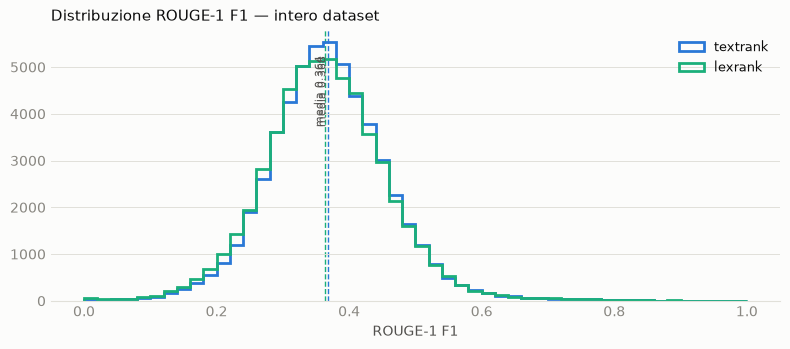

In [2]:
if full_dati:
    print('Medie complessive (intero dataset):')
    display(su.tabella_medie(full_dati))
    for metodo, d in full_dati.items():
        per_split = d['agg']['per_split']
        print(f"\n{metodo} — per split:")
        per_split_df = pd.DataFrame(per_split).T
        colonne_presenti = [c for c in su.METRICHE_CHIAVE if c in per_split_df.columns]
        display(per_split_df[['n_esempi'] + colonne_presenti].round(4))

    # Distribuzione del ROUGE-1 F1: istogrammi a gradini sovrapposti (stessa scala)
    fig, ax = plt.subplots(figsize=(8, 3.6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    bins = np.linspace(0, 1, 51)
    for metodo, d in full_dati.items():
        ax.hist(d['df']['rouge1_f1'], bins=bins, histtype='step', linewidth=2,
                color=COLORI[metodo], label=metodo, zorder=2)
        media = d['df']['rouge1_f1'].mean()
        ax.axvline(media, color=COLORI[metodo], linewidth=1, linestyle='--', zorder=1)
        ax.annotate(f'media {media:.3f}', (media, ax.get_ylim()[1] * 0.9),
                    fontsize=8, color=INK2, rotation=90, va='top', ha='right')
    ax.set_title('Distribuzione ROUGE-1 F1 — intero dataset', color=INK, loc='left', fontsize=11)
    ax.set_xlabel('ROUGE-1 F1')
    ax.grid(axis='y', color=GRID, linewidth=0.7, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(length=0)
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna metrica 'full' disponibile: eseguire i notebook 01/02 con SCOPE='full'.")